# Promptable segmentation with SAM 3

Segment every object matching a concept (a short text phrase or a bounding box) using Meta's [Segment Anything Model 3](https://huggingface.co/facebook/sam3).

**What's in this recipe:**

- Segment a single object from a text prompt
- Segment many instances of a concept at once
- Segment a specific region with a bounding box
- Segment objects across the frames of a video
- Apply SAM 3 to three customer use cases: satellite imagery, medical scans, and solar inspection

## Problem

Classical segmentation models output a fixed set of class labels. SAM 3 instead performs *promptable concept segmentation*: you describe what you want with a short noun phrase ("zebra", "car") or a bounding box, and the model returns one instance mask for every matching object.

| Approach | Output | Prompting |
|----------|--------|-----------|
| Panoptic segmentation (DETR) | Fixed COCO classes | None |
| Promptable segmentation (SAM 3) | Per-instance binary masks | Text and/or boxes |

## Solution

Use the `sam_for_segmentation` UDF in `pixeltable.functions.huggingface`. It returns a typed result with one entry per detected instance: a confidence `score`, a bounding `box`, and a binary `mask`. The `overlay_segmentation` vision UDF accepts those masks directly, so you can visualize results without any glue code.

> **Note:** `facebook/sam3` is a gated model. Request access on its [model page](https://huggingface.co/facebook/sam3), then authenticate with `huggingface-cli login` (or set the `HF_TOKEN` environment variable) before running this notebook.

In [ ]:
%pip install -qU pixeltable torch transformers

### Set up a table of images

We load five images: a grazing zebra, a bento box full of food, an aerial view of the Davis-Monthan AMARG aircraft boneyard, a chest X-ray, and a solar array. A Pixeltable table stores the originals; every example below computes its segmentation on the fly with `select`, so nothing extra is persisted.

In [1]:
import pixeltable as pxt
from pixeltable.functions.huggingface import (
    sam_automatic_mask_generation,
    sam_for_segmentation,
)
from pixeltable.functions.vision import bboxes_draw, overlay_segmentation

pxt.drop_dir('sam3_demo', force=True)
pxt.create_dir('sam3_demo')

base_url = 'https://raw.githubusercontent.com/pixeltable/pixeltable/main/docs/resources/images'

images = pxt.create_table(
    'sam3_demo/images', {'name': pxt.String, 'image': pxt.Image}
)
images.insert(
    [
        {'name': 'zebra', 'image': f'{base_url}/000000000034.jpg'},
        {'name': 'bento', 'image': f'{base_url}/000000000009.jpg'},
        {'name': 'boneyard', 'image': f'{base_url}/amarg-boneyard.jpg'},
        {'name': 'chest_xray', 'image': f'{base_url}/chest-xray.jpg'},
        {'name': 'solar_farm', 'image': f'{base_url}/solar-farm.jpg'},
    ]
)

Connected to Pixeltable database at: postgresql+psycopg://postgres:@/pixeltable?host=/Users/cpestano/.pixeltable/pgdata
Created directory 'sam3_demo'.
Created table 'images'.
Inserted 5 rows with 0 errors in 0.84 s (5.98 rows/s)


5 rows inserted.

### Segment from a text prompt

Pass a short noun phrase as `text`. SAM 3 returns one binary mask per matching instance. Here we segment the zebra and overlay the mask on the original image with `overlay_segmentation`.

image,segmented
,

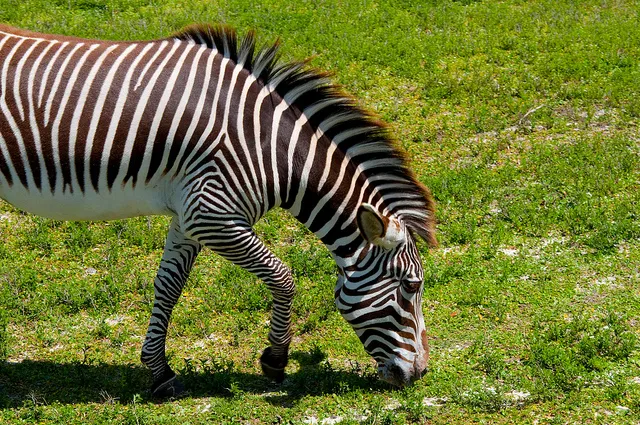
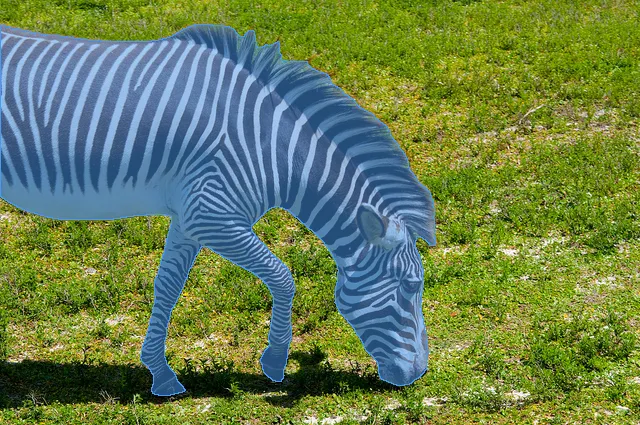

In [5]:
images.select(
    images.image,
    segmented=overlay_segmentation(
        images.image,
        sam_for_segmentation(images.image, text='zebra').masks,
        draw_contours=True,
    ),
).where(images.name == 'zebra').collect()

### Segment many instances automatically

A single call to `sam_automatic_mask_generation` segments every object it detects in the image and returns unlabeled masks. He we segment a bento box of fruit and overlay the masks on the image.

segmented
""

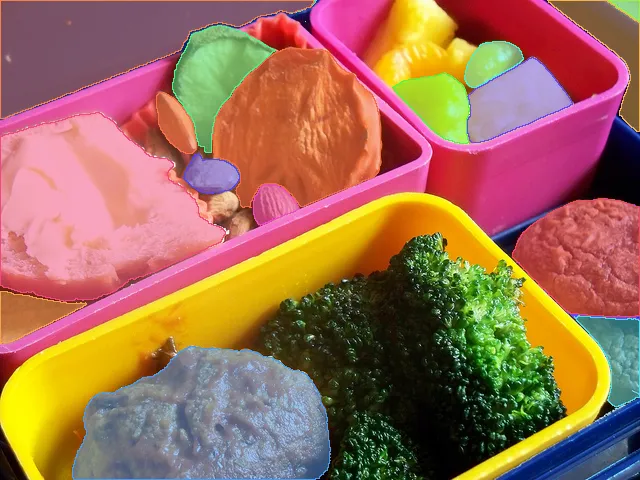

In [4]:
images.select(
    segmented=overlay_segmentation(
        images.image,
        sam_automatic_mask_generation(images.image).masks,
        draw_contours=True,
    ),
).where(images.name == 'bento').collect()

### Segment a region with a bounding box

Skip the text prompt and pass a bounding box in `[x1, y1, x2, y2]` pixel coordinates to segment whatever concept that region contains.

image,segmented
,

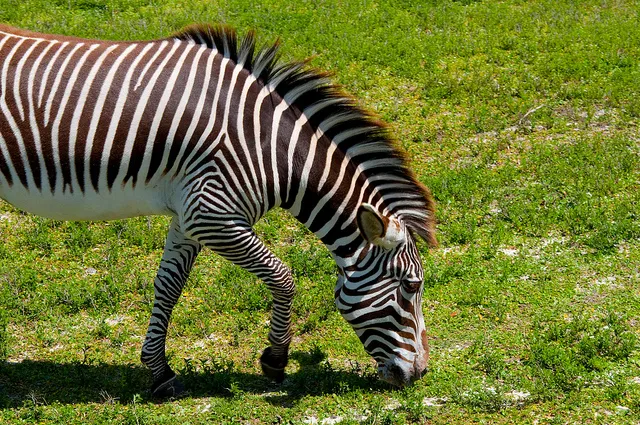
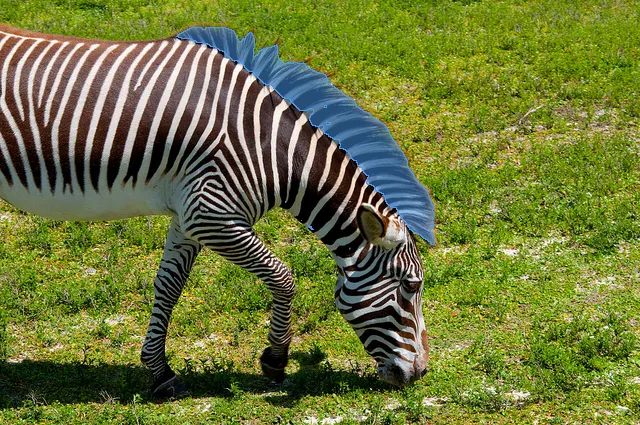

In [4]:
images.select(
    images.image,
    segmented=overlay_segmentation(
        images.image,
        sam_for_segmentation(
            images.image, input_boxes=[[10, 30, 470, 300]]
        ).masks,
        draw_contours=True,
    ),
).where(images.name == 'zebra').collect()

## Segment objects across a video

Segmentation works on video frames too. We split the first three seconds of a Bangkok traffic clip into frames at the video's native frame rate with `frame_iterator`, segment every `car`, overlay the masks, and reassemble the result with the `make_video` aggregator. Extracting and rebuilding at the same frame rate keeps the output at the original tempo.

SAM segments each frame independently and does not track objects across frames, so the per-instance colors would otherwise flicker from frame to frame. To keep the overlay stable, we merge every car mask in a frame into a single region, so all cars share one consistent color.

In [5]:
from pixeltable.functions.huggingface import sam_for_video_segmentation
from pixeltable.functions.video import clip, make_video

pxt.drop_dir('sam3_video', force=True)
pxt.create_dir('sam3_video')

bangkok = 'https://raw.githubusercontent.com/pixeltable/pixeltable/main/docs/resources/bangkok.mp4'

videos = pxt.create_table('sam3_video/videos', {'video': pxt.Video})
videos.add_computed_column(
    clipped_video=clip(videos.video, start_time=0, end_time=2)
)
videos.insert([{'video': bangkok}])

frames = pxt.create_view(
    'sam3_video/frames',
    videos,
    iterator=sam_for_video_segmentation(
        videos.clipped_video, text=['car', 'motorcycle'], fps=5
    ),
)

Created directory 'sam3_video'.
Created table 'videos'.
Added 0 column values with 0 errors in 0.00 s
Inserted 1 row with 0 errors in 1.88 s (0.53 rows/s)


segmented_video
""

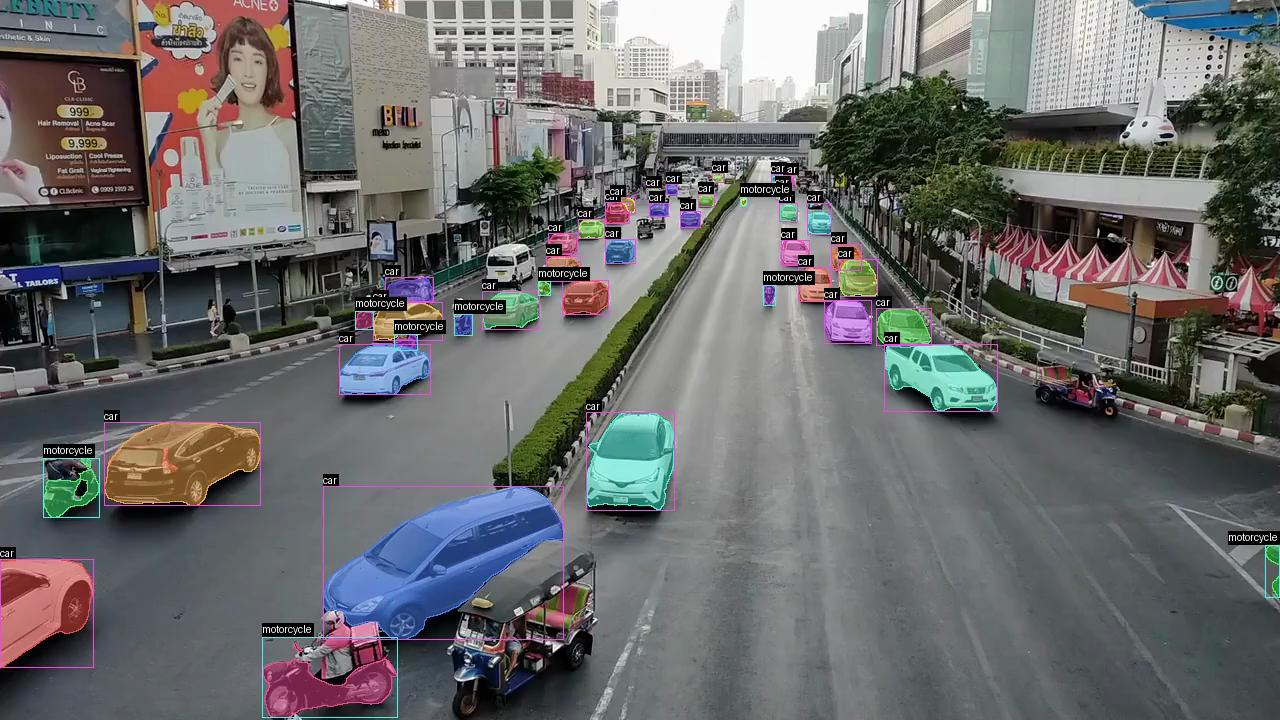

In [ ]:
# bangkok.mp4 plays at 5 fps; rebuild at the same rate to keep the tempo.
# Note: You can improve the final frame's quality by padding the end then trimming it off
# this is because SAMv3 looks ahead a few frames for object tracking
frames.group_by(videos).select(
    segmented_video=make_video(
        frames.pos,
        bboxes_draw(
            img=overlay_segmentation(
                frames.frame, frames.masks, draw_contours=True
            ),
            boxes=frames.boxes.to_list(),
            labels=frames.labels.to_list(),
        ),
        fps=5,
    )
).collect()

## Defense and intelligence: count aircraft in a satellite image

Geospatial imagery often shows hundreds of vehicles, vessels, or aircraft in a single frame, and the assets of interest change from mission to mission. SAM 3's open-vocabulary text prompt picks every instance out of the scene in a single pass; the `scores` column lets you threshold by confidence before counting or feeding the masks into a downstream tracker.

Added 15 column values with 0 errors in 34.06 s (0.44 rows/s)


stitched
""

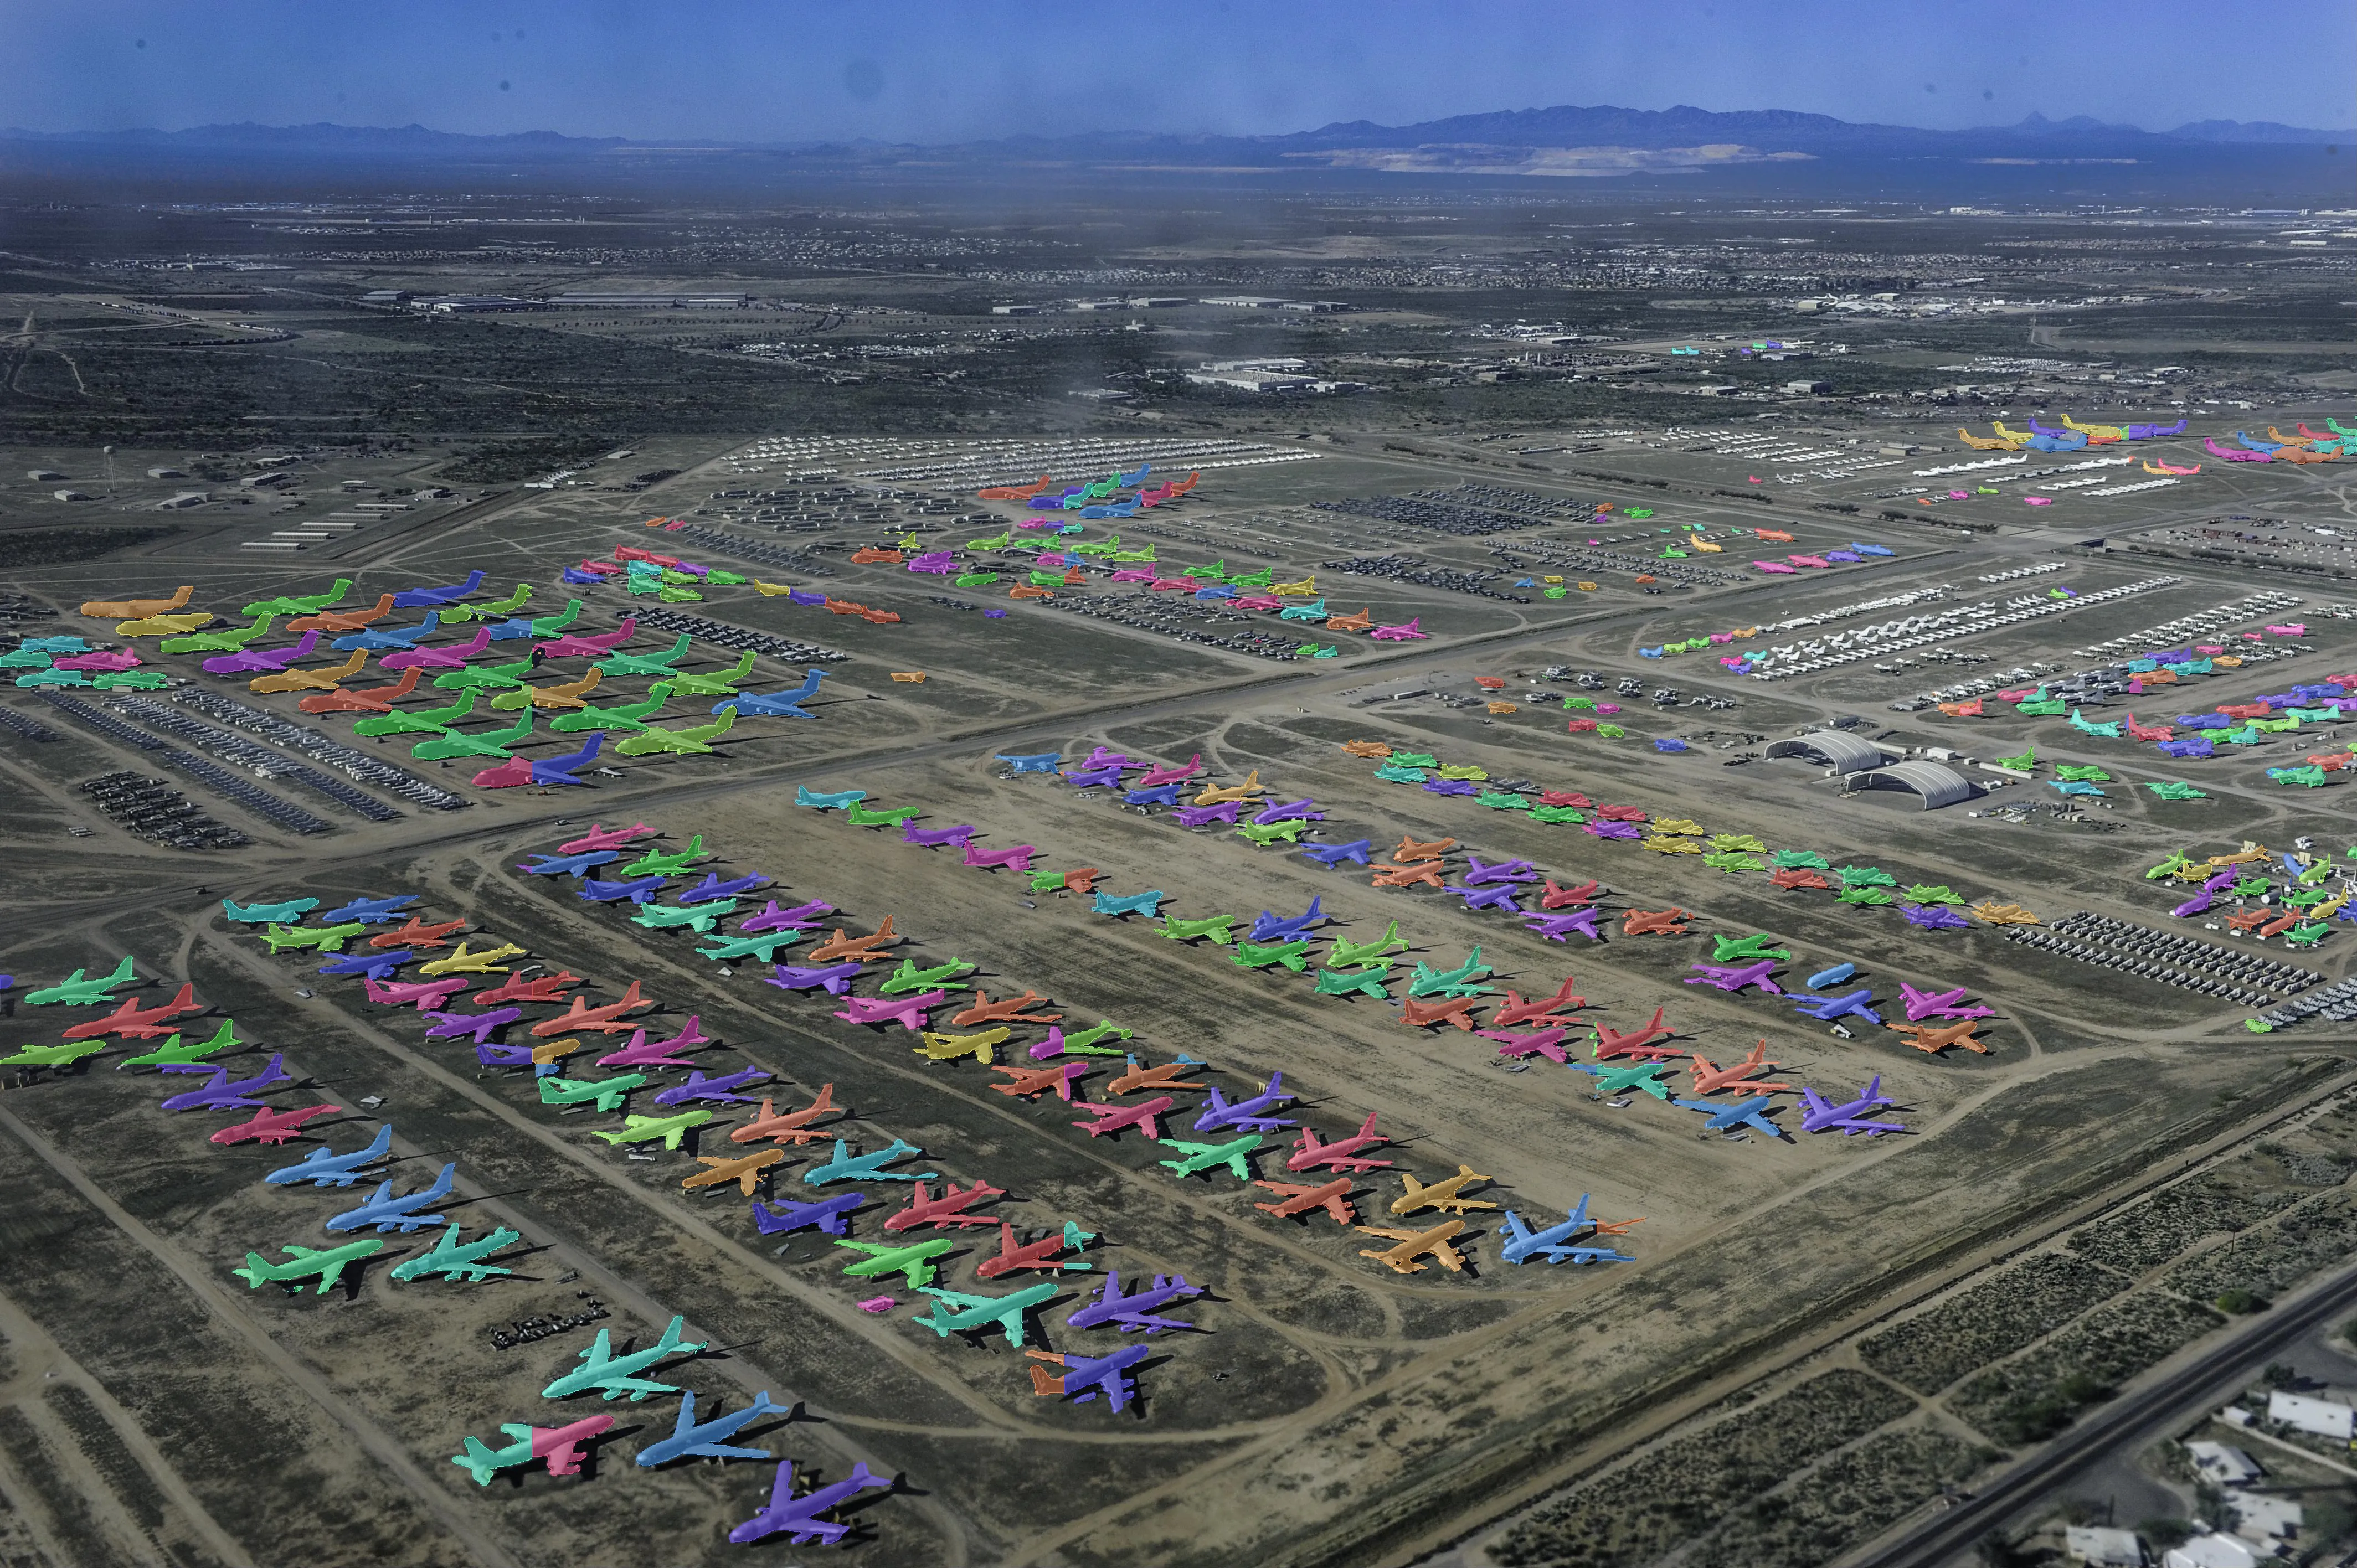

In [14]:
from pixeltable.functions.image import stitch_tiles, tile_iterator

tiles = pxt.create_view(
    'sam3_demo/tiles',
    images.where(images.name == 'boneyard'),
    iterator=tile_iterator(
        images.image, tile_size=(1006, 1006), overlap=(45, 45)
    ),
)

tiles.add_computed_column(
    segmented_tile=overlay_segmentation(
        tiles.tile,
        sam_for_segmentation(tiles.tile, text='aircraft').masks,
        draw_contours=True,
    )
)

tiles.group_by(tiles.image).select(
    stitched=stitch_tiles(
        tiles.segmented_tile,
        tiles.tile_box,
        tiles.image.width,
        tiles.image.height,
    )
).collect()

## Medical imaging: segment the lungs in a chest X-ray

SAM 3 is trained on natural images, so grayscale modalities like X-ray, CT, and MRI sit outside its training distribution and a free-form text prompt is less reliable than on RGB scenes. A high-contrast structure like the lungs in a PA chest X-ray is usually within reach. For anatomy SAM 3 doesn't pick up zero-shot, a bounding box around the region of interest is the radiologist's fallback and produces a clean mask without any text prompt.

image,segmented
,

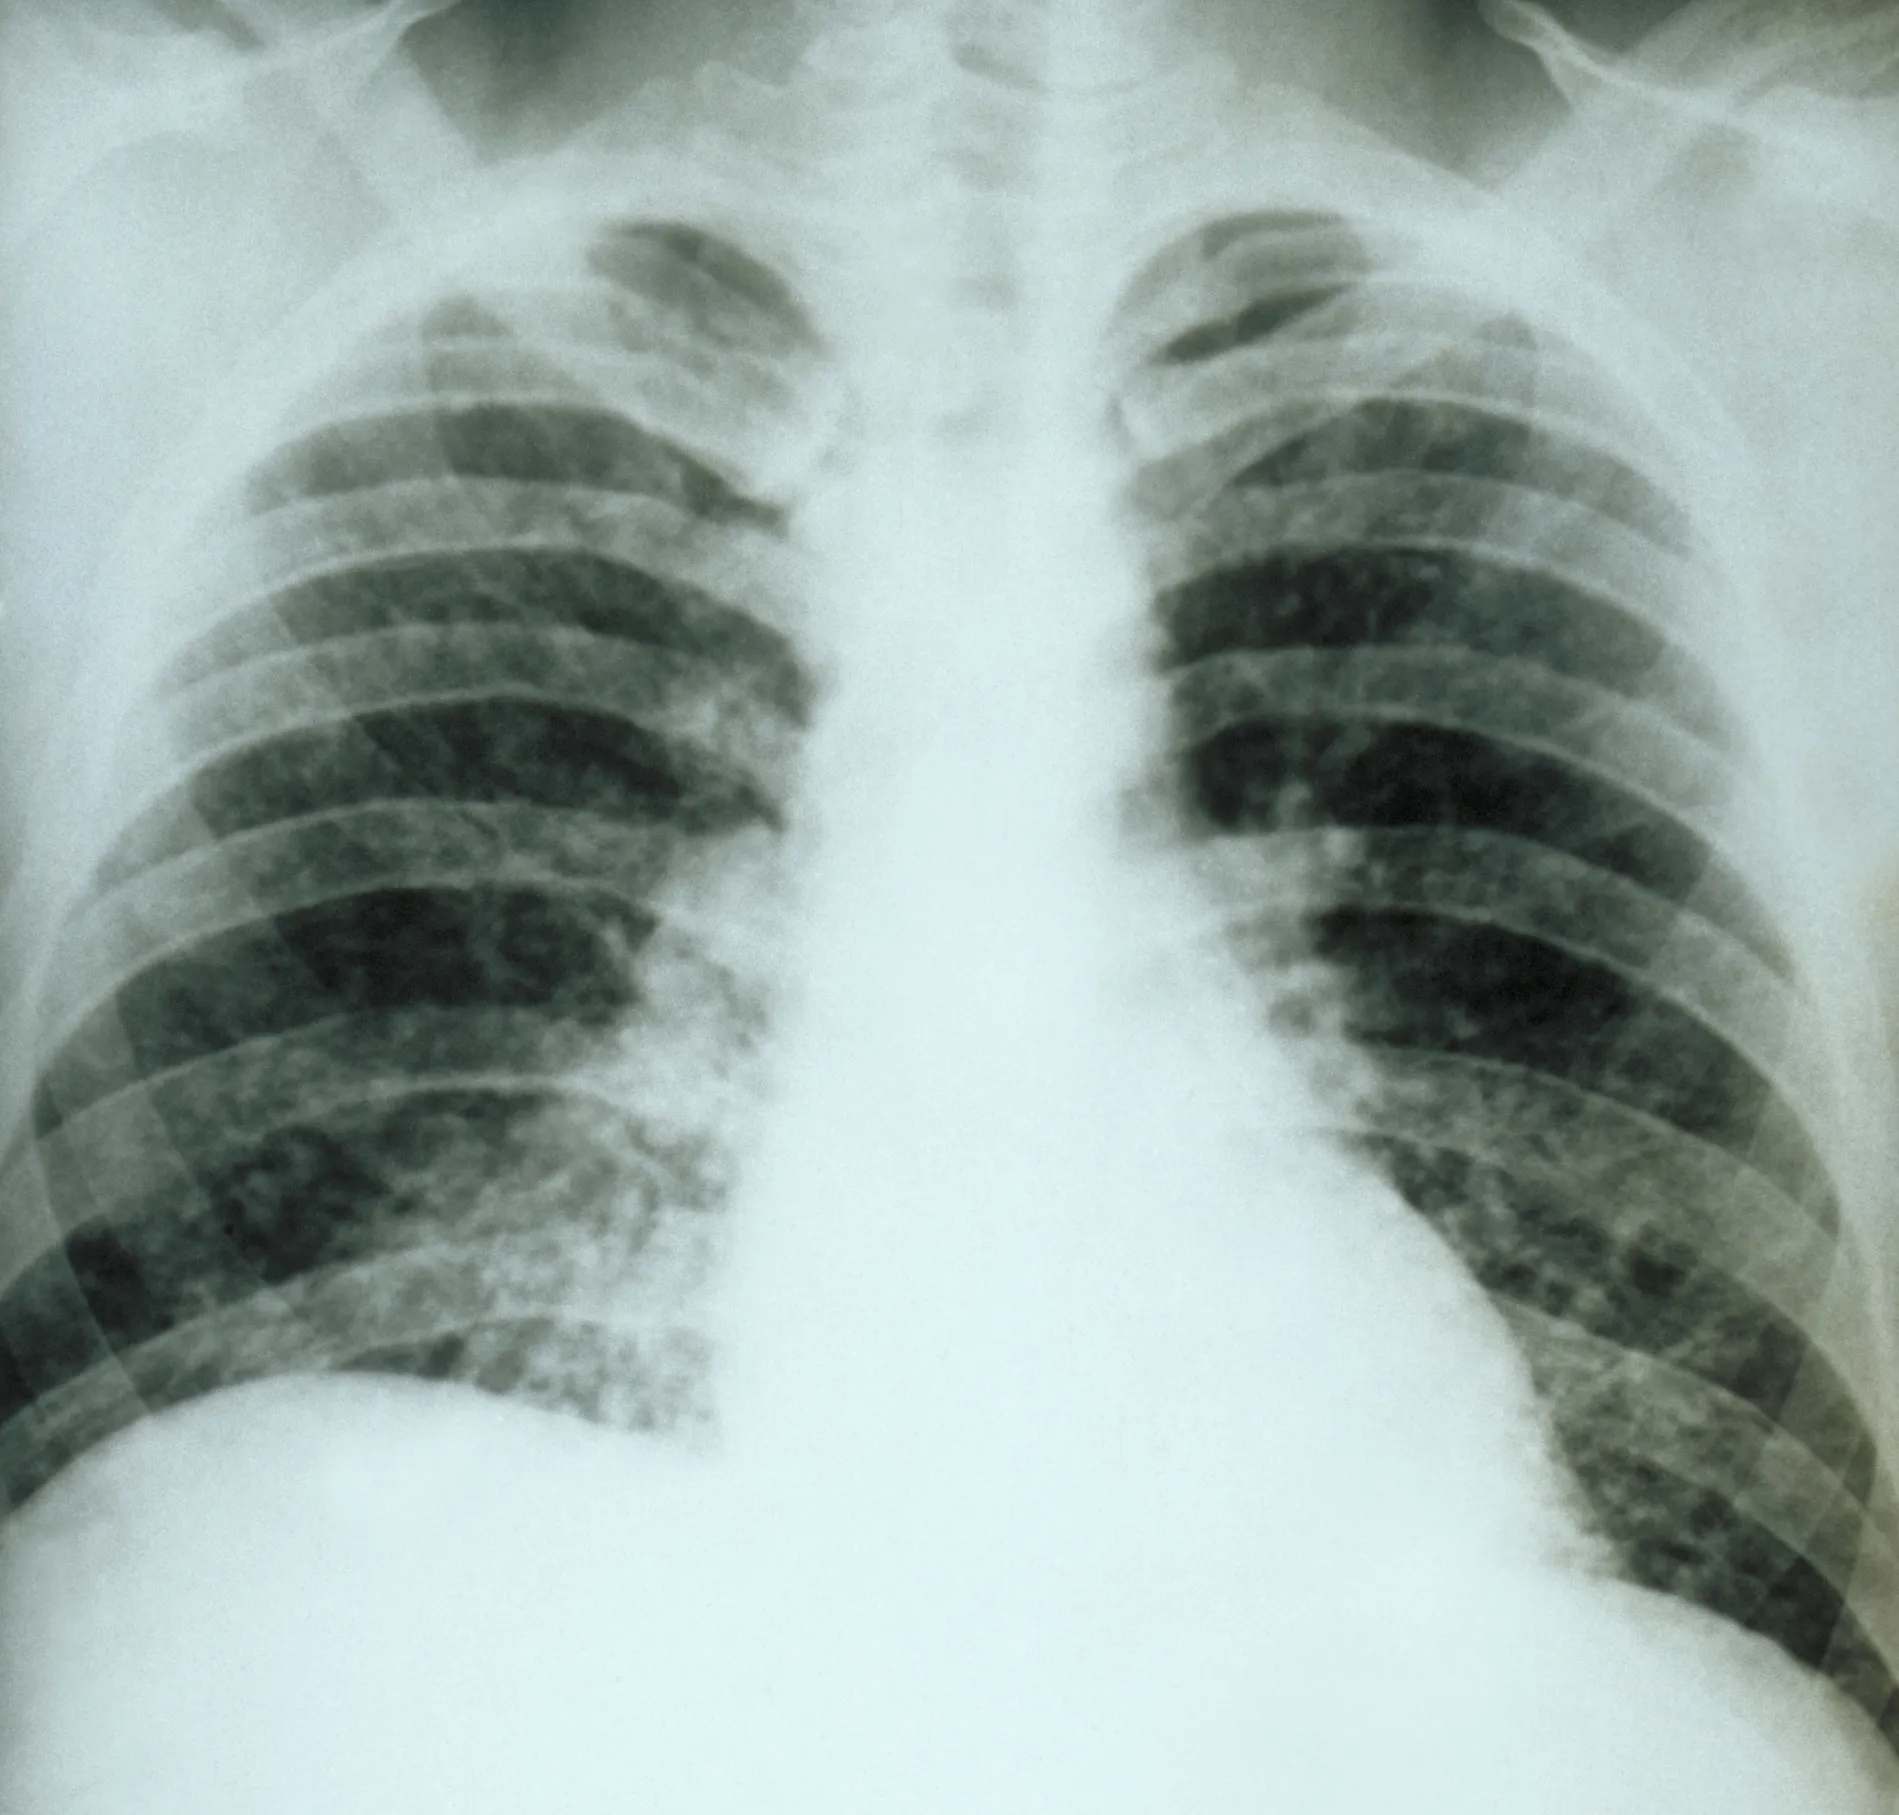
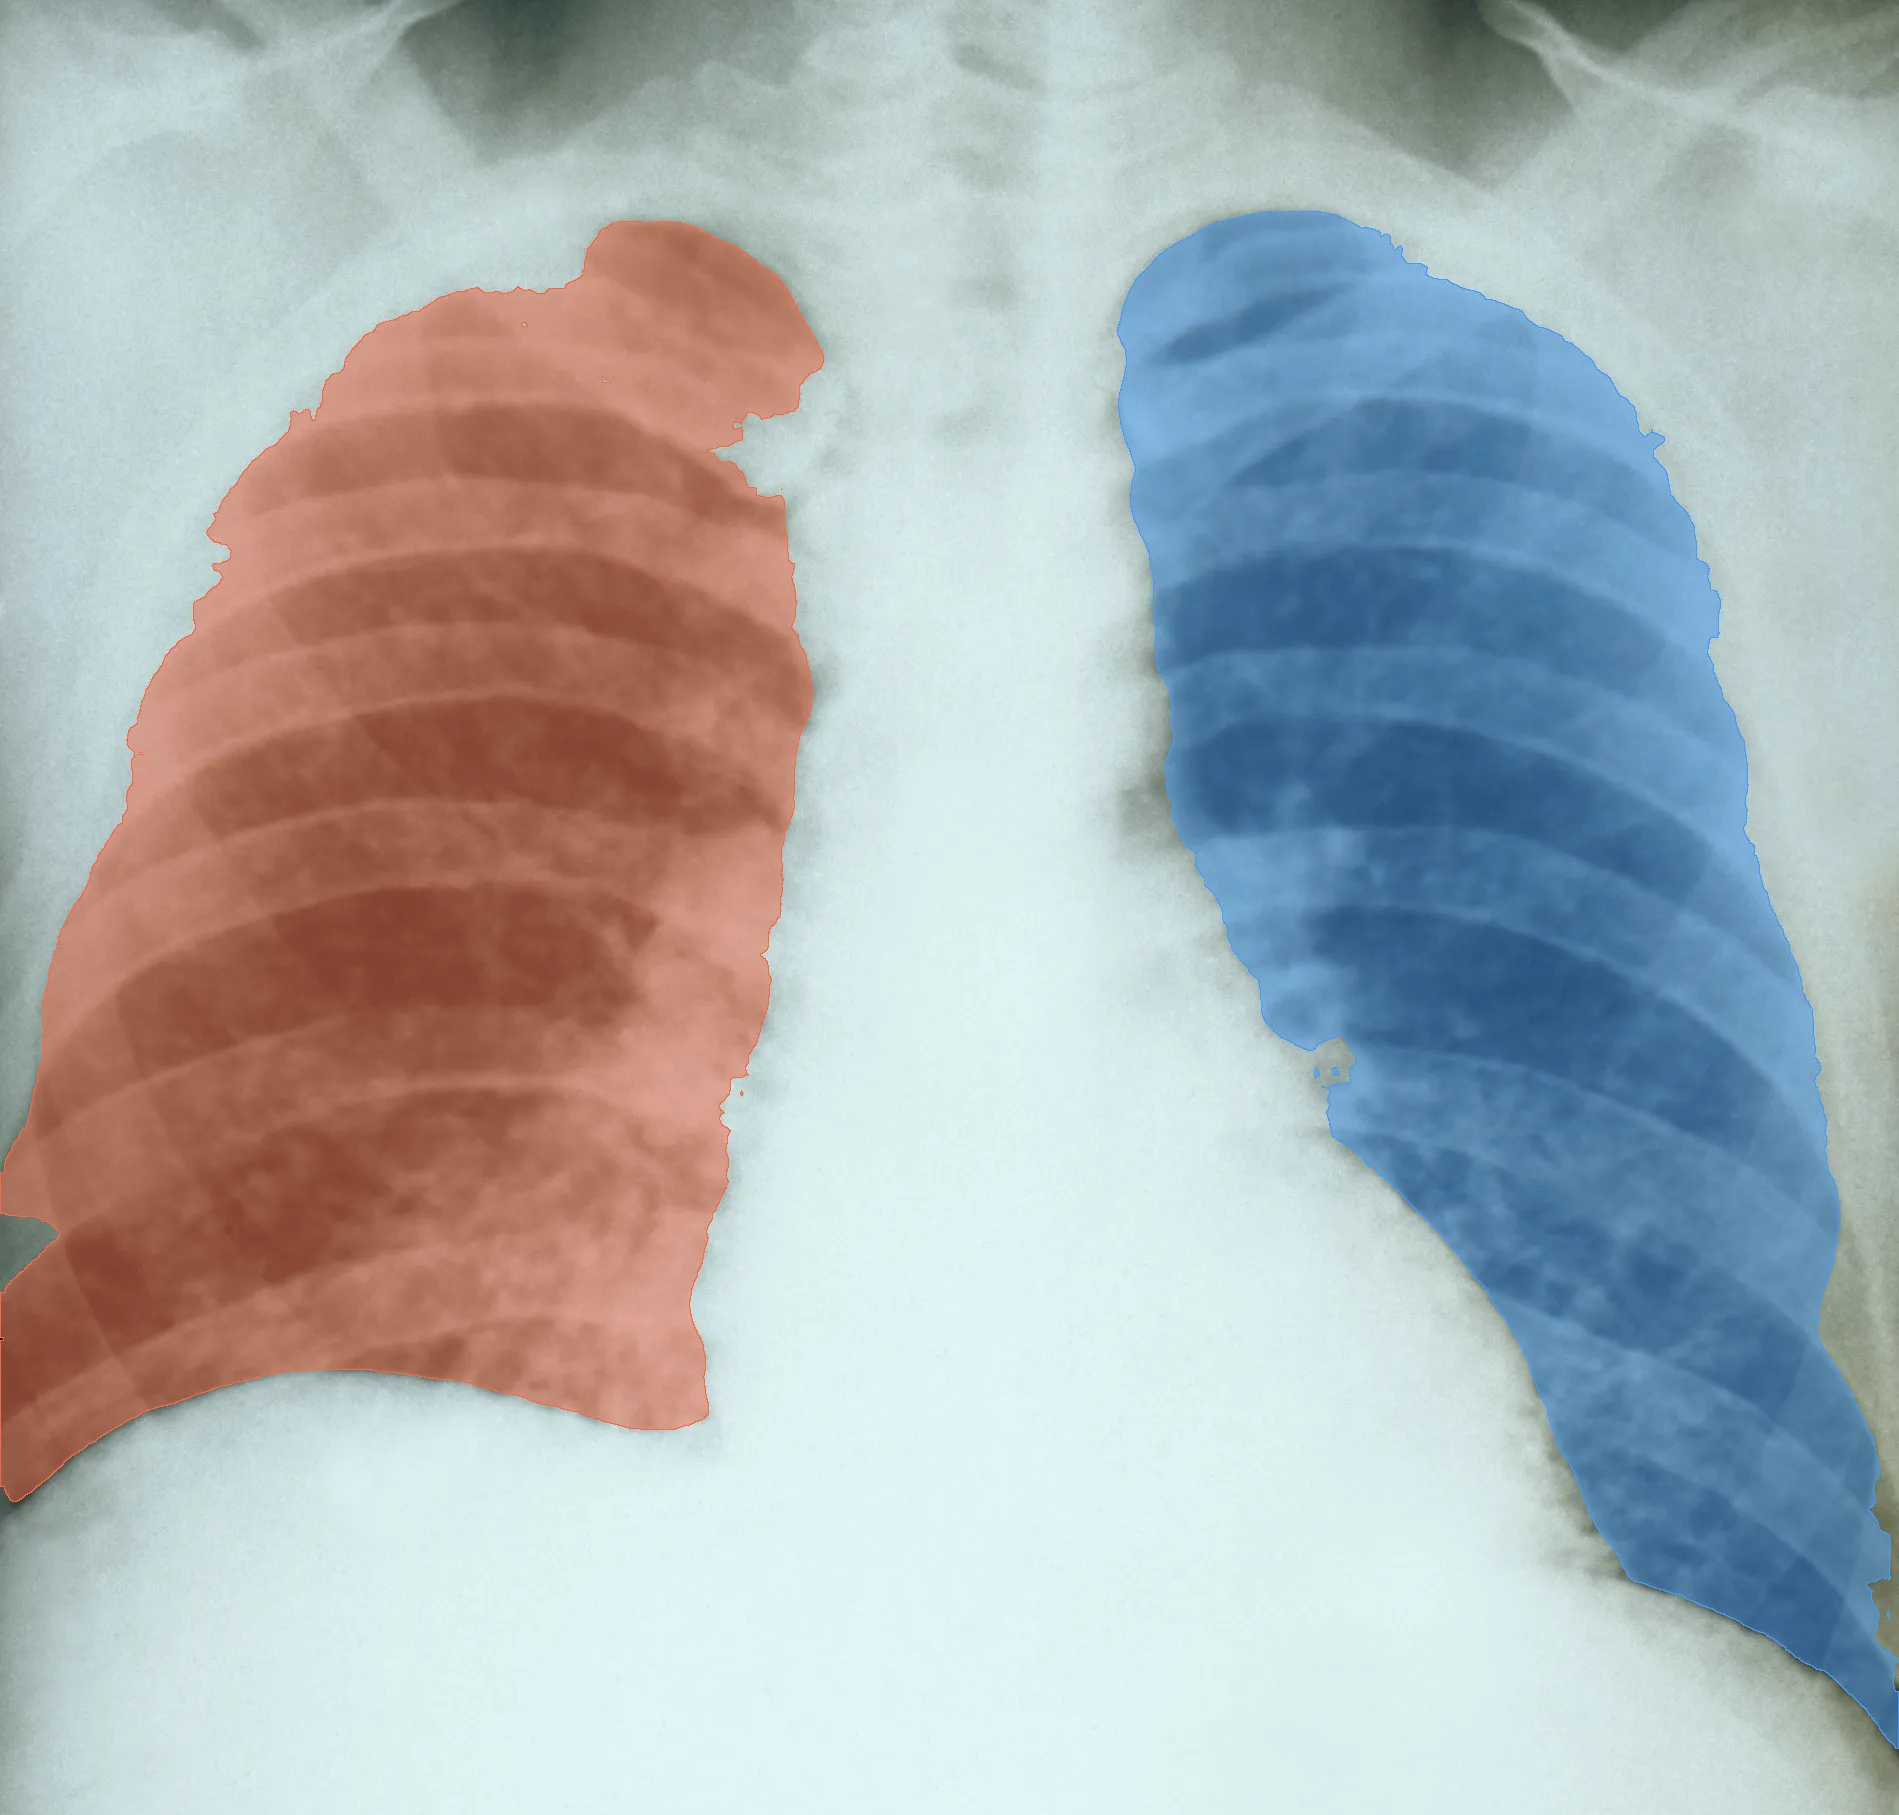

In [15]:
images.select(
    images.image,
    segmented=overlay_segmentation(
        images.image,
        sam_for_segmentation(images.image, text='lung').masks,
        draw_contours=True,
    ),
).where(images.name == 'chest_xray').collect()

## Energy infrastructure: inspect a solar array

Drone and aerial inspection of utility-scale solar, wind, and transmission assets is dominated by one bottleneck: finding every instance of the asset in a frame before any defect classifier runs. A single concept prompt returns per-panel masks that can be persisted in a computed column and chained into downstream UDFs (thermal-anomaly detection, soiling estimation, and so on).

image,segmented
,

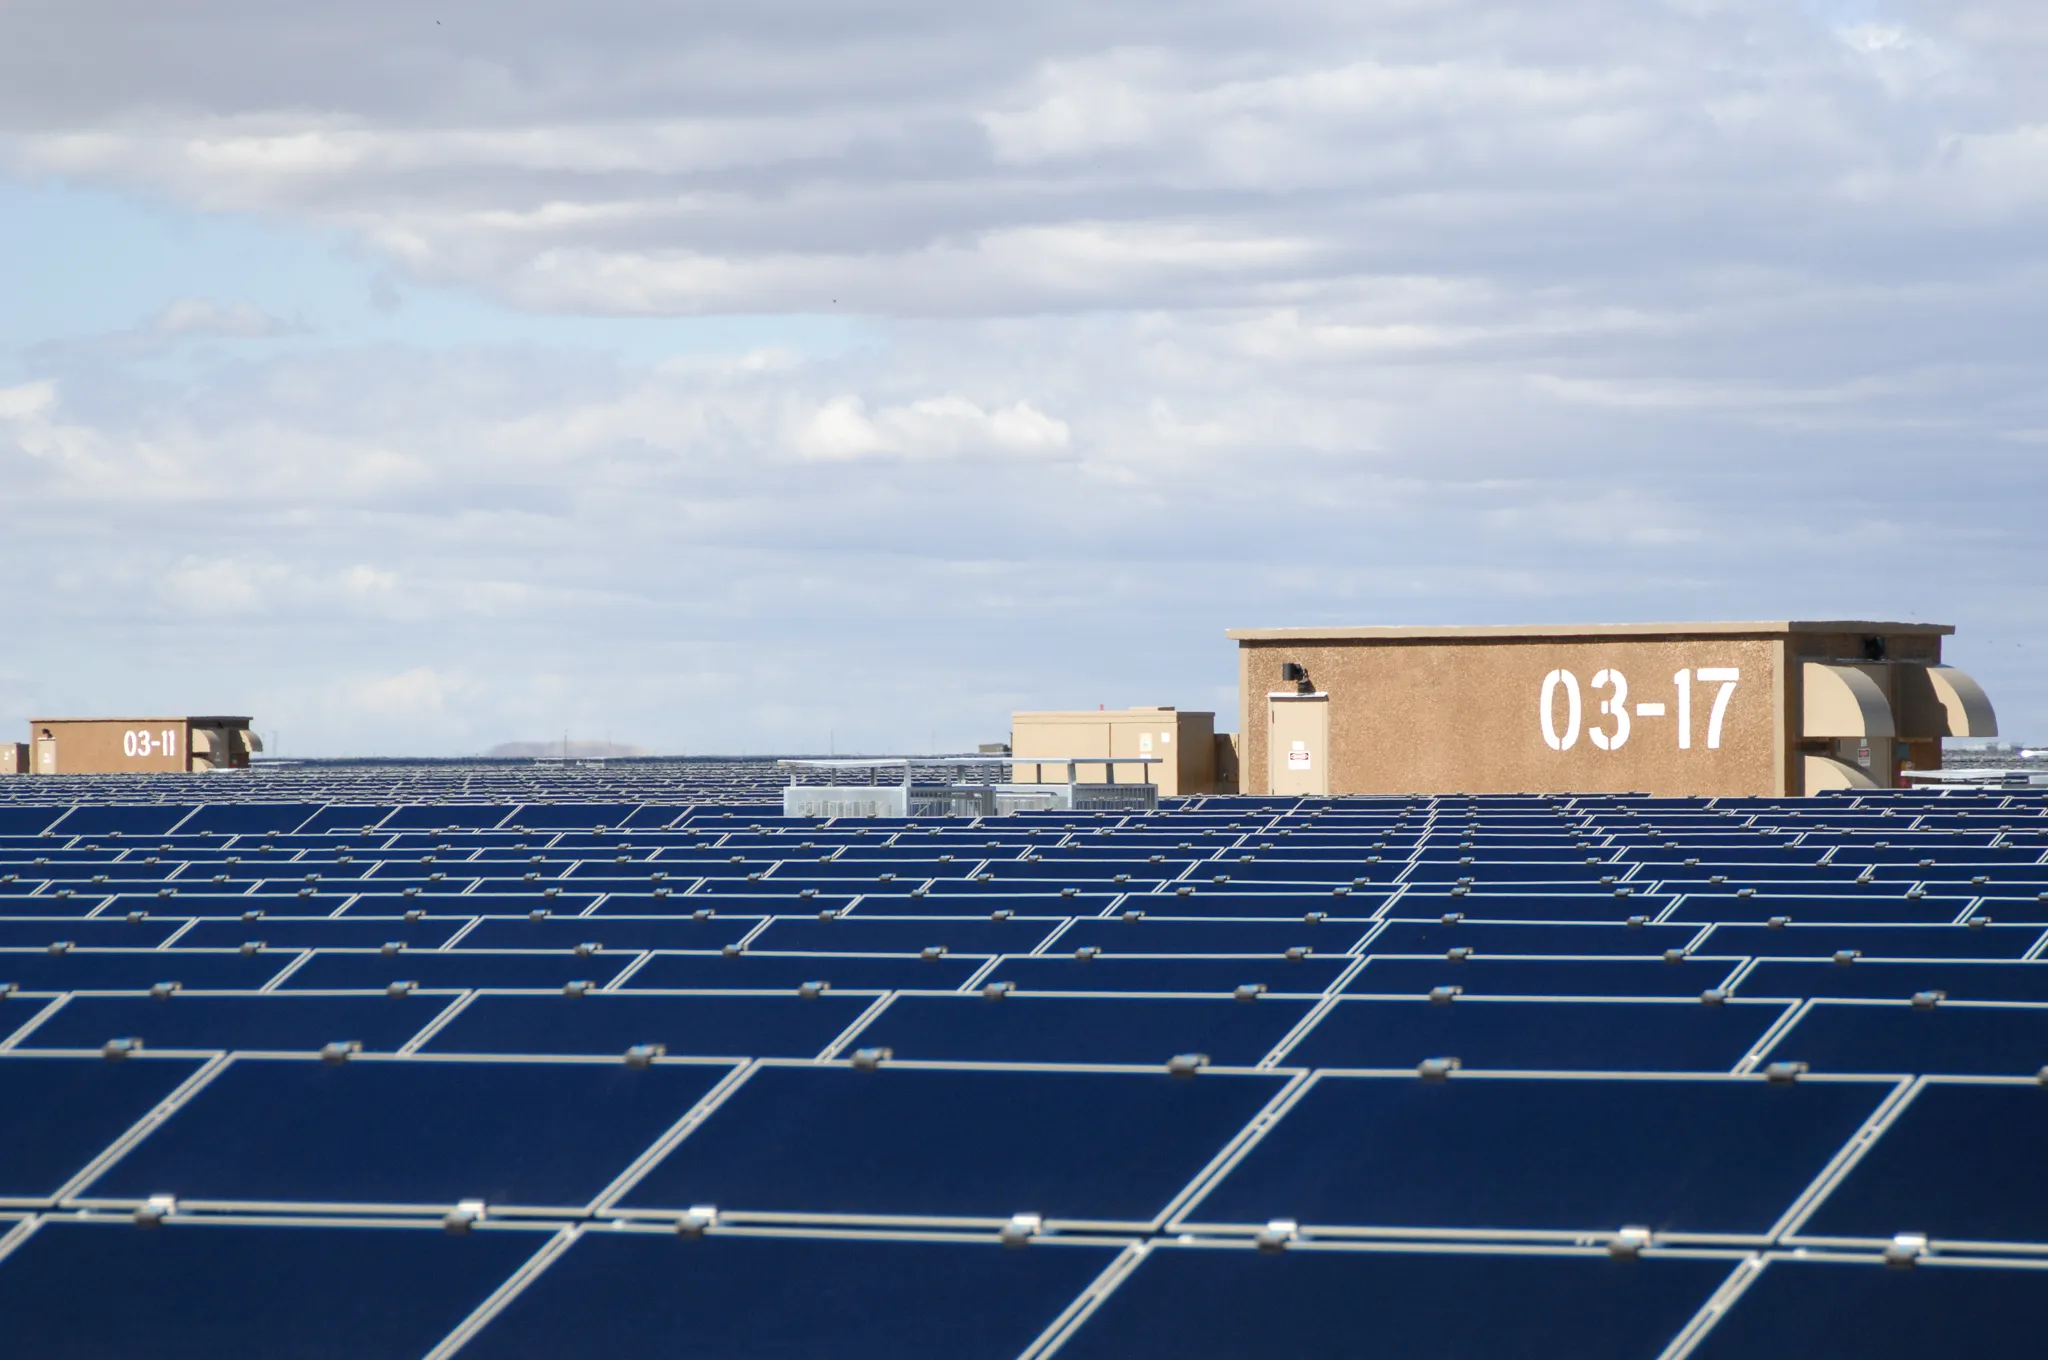
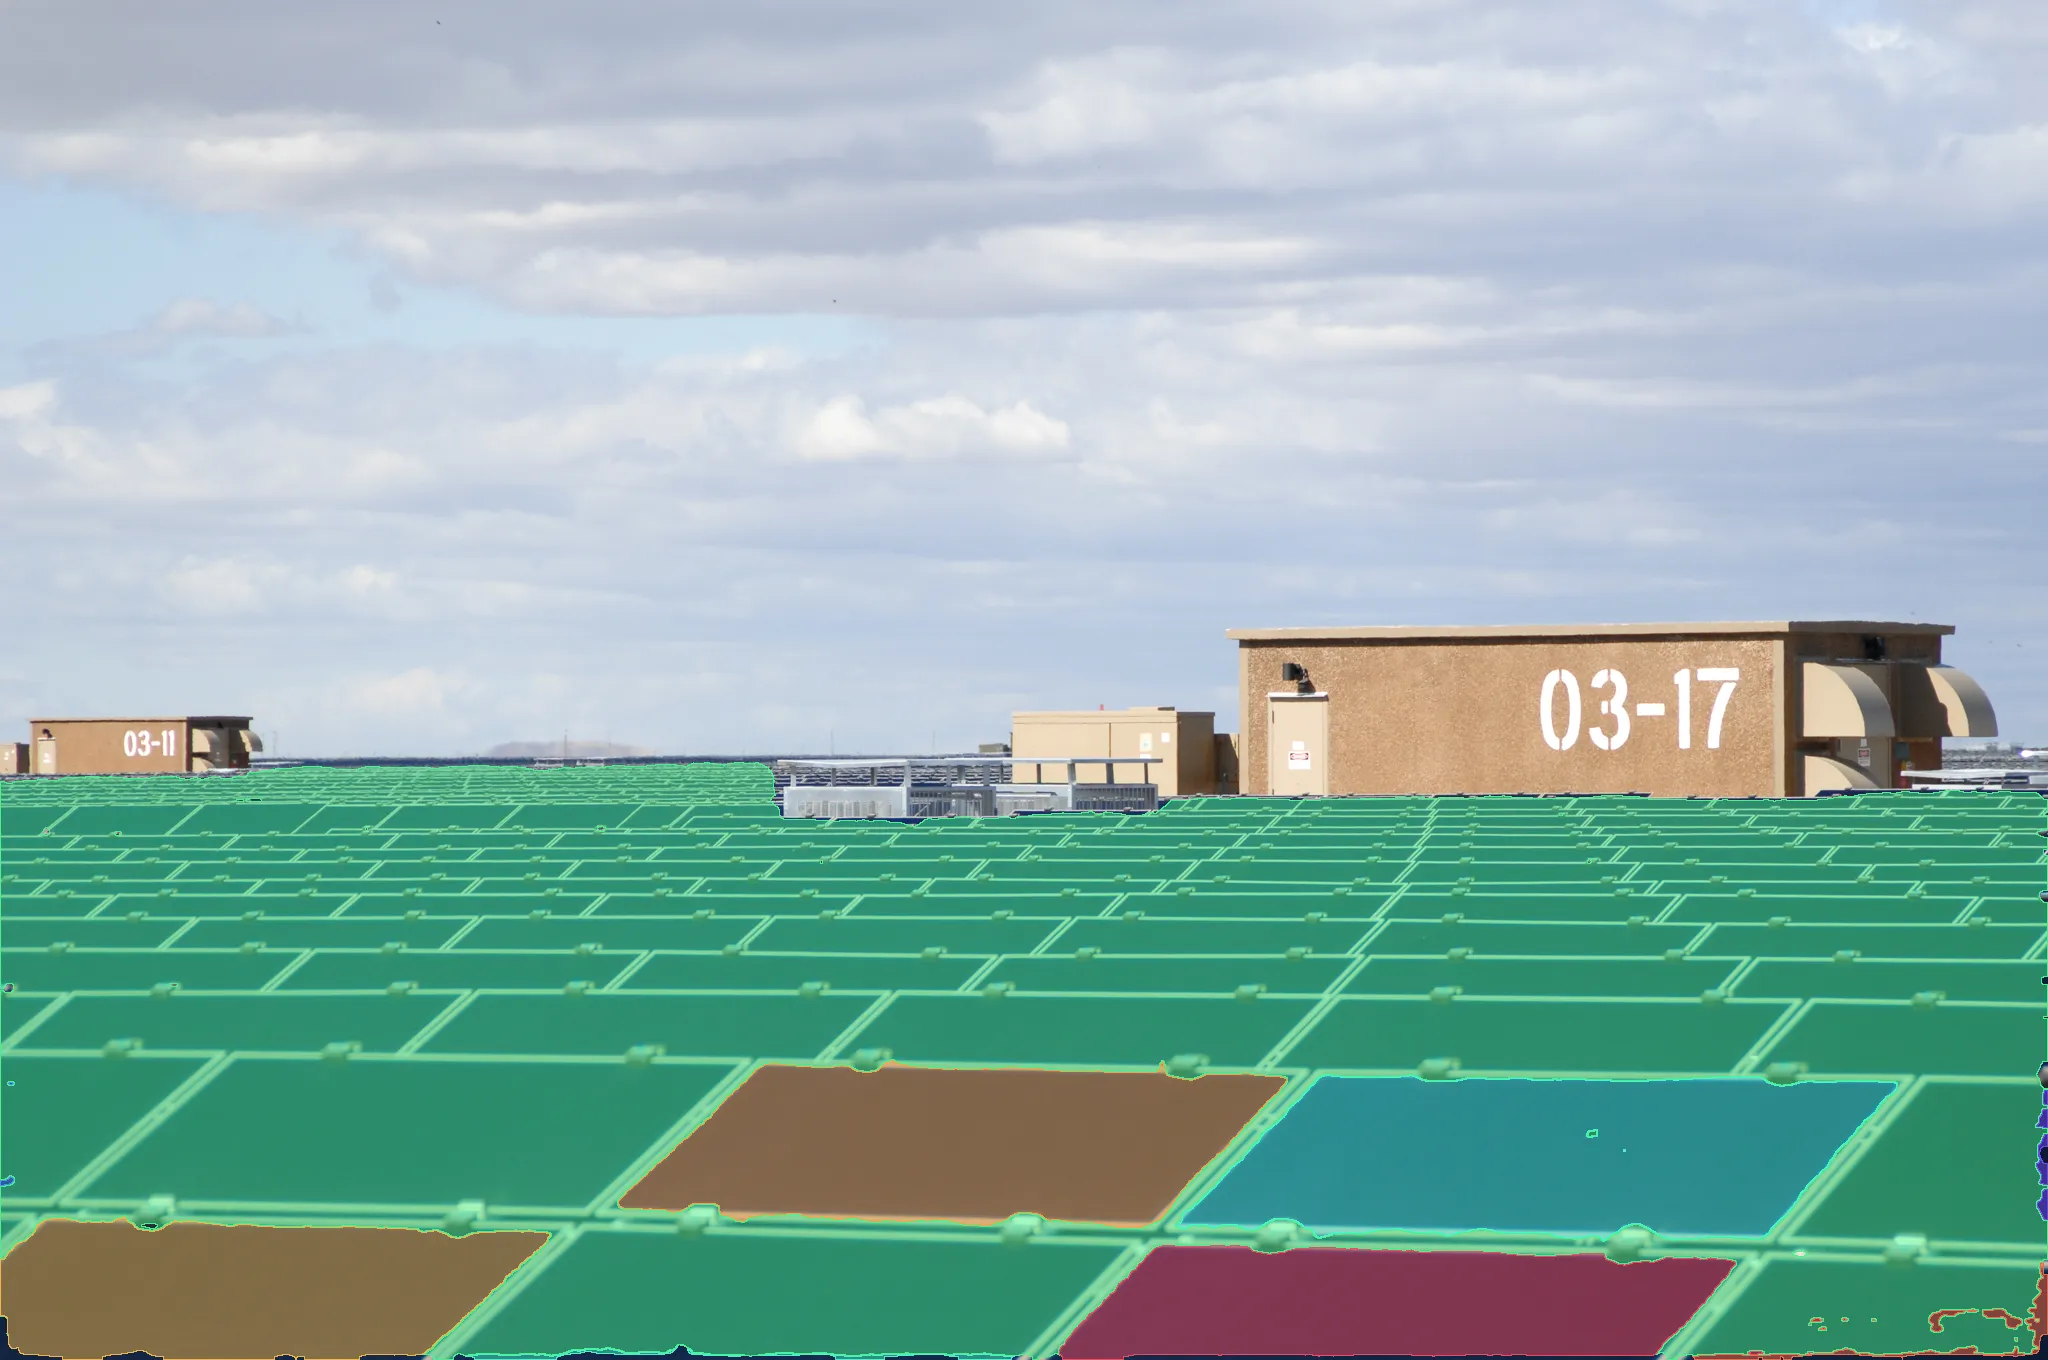

In [16]:
images.select(
    images.image,
    segmented=overlay_segmentation(
        images.image,
        sam_for_segmentation(images.image, text='solar panel').masks,
        draw_contours=True,
    ),
).where(images.name == 'solar_farm').collect()

## Explanation

SAM 3 differs from earlier segmentation models in two ways:

1. **Concept-based prompting.** Instead of choosing from a fixed taxonomy, you describe the concept with free-form text, bounding boxes, or both.
1. **Instance masks for every match.** One forward pass returns a mask, score, and box for each matching instance.

Because `sam_for_segmentation` is an ordinary UDF, you can store its result in a computed column to segment new rows automatically, or compute it on the fly with `select` as we did here. `overlay_segmentation` consumes the per-instance mask stack directly, so visualizing results never requires reshaping arrays by hand.

## See also

- [Compare object detection and panoptic segmentation](./img-detection-vs-segmentation)
- [Detect objects in images](./img-detect-objects)
- [SAM 3 documentation](https://huggingface.co/docs/transformers/model_doc/sam3)